## FITS → Zarr conversion (Stokes I and V)

Collect deep pbcorr images across all Wideband-qualified hours for the selected
day, symlink them under `/lustre/claw/`, and convert to Zarr stores in
`/fast/claw/`.

| Stokes | FITS pattern | Output Zarr stem |
|--------|--------------|------------------|
| I | `{NN}MHz-I-Deep-Taper-Robust-0.75-image-{stamp}.pbcorr.fits` | `pipelineQA-I-Deep-Taper-Robust-0.75-{YYYYMMDD}.zarr` |
| V | `{NN}MHz-V-Taper-Deep-image-{stamp}.pbcorr.fits` | `pipelineQA-V-Taper-Deep-{YYYYMMDD}.zarr` |

If the output Zarr for `SELECT_DAY` already exists, conversion is **skipped**.
The LM reference grid is resampled to the **82 MHz** image pixel size on first build.

Stokes **I** is converted first. Stokes **V** is staged with beam headers copied from
the matching I files, then converted using the **same LM reference grid** from the I Zarr.


In [1]:
from __future__ import annotations

import os
import re
from pathlib import Path
from typing import Sequence

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from astropy.io import fits

import ovro_lwa_portal
from ovro_lwa_portal.fits_to_zarr_xradio import (
    _lm_reference_from_existing_zarr,
    convert_fits_dir_to_zarr,
)

PIPELINE_ROOT = Path("/lustre/pipeline/images")
SYMLINK_ROOT = Path("/lustre/claw")
ZARR_ROOT = Path("/fast/claw")

RUN_PATTERN = re.compile(r"Run_(\d{8})_(\d{6})")
DATE_PATTERN = re.compile(r"^\d{4}-\d{2}-\d{2}$")
HOUR_PATTERN = re.compile(r"^\d{2}h$")

WIDEBAND_QA = Path("Wideband/thermal_noise_vs_subband.png")
I_FITS_GLOB = "*I-Deep-Taper-Robust-0.75-image*.pbcorr.fits"
V_FITS_GLOB = "*V-Taper-Deep-image*.pbcorr.fits"
REF_SUBBAND = "82MHz"
I_QA_ZARR_STEM = "pipelineQA-I-Deep-Taper-Robust-0.75"
V_QA_ZARR_STEM = "pipelineQA-V-Taper-Deep"


In [2]:
def run_sort_key(run_dir: Path) -> str:
    """Sort key from Run_YYYYMMDD_HHMMSS directory name."""
    match = RUN_PATTERN.match(run_dir.name)
    if match is None:
        return run_dir.name
    return match.group(1) + match.group(2)


def select_run_dir(day_dir: Path) -> Path | None:
    """Pick the newest Run_* that has Wideband thermal-noise QA."""
    runs = [
        path
        for path in day_dir.iterdir()
        if path.is_dir() and path.name.startswith("Run_") and (path / WIDEBAND_QA).is_file()
    ]
    if not runs:
        return None
    return max(runs, key=run_sort_key)


def list_subbands(run_dir: Path) -> list[str]:
    """List subband directories (e.g. 23MHz) under a run — no file I/O."""
    return sorted(
        path.name
        for path in run_dir.iterdir()
        if path.is_dir() and path.name.endswith("MHz")
    )


def discover_hour_bins(root: Path) -> list[str]:
    return sorted(
        (path.name for path in root.iterdir() if path.is_dir() and HOUR_PATTERN.match(path.name)),
        key=lambda name: int(name[:-1]),
    )


def scan_coverage(root: Path = PIPELINE_ROOT) -> pd.DataFrame:
    """Build one row per (LST hour bin, observation day) from directory names."""
    rows: list[dict[str, object]] = []

    for hour in discover_hour_bins(root):
        hour_dir = root / hour
        for day_dir in sorted(hour_dir.iterdir()):
            if not day_dir.is_dir() or not DATE_PATTERN.match(day_dir.name):
                continue

            all_runs = [p for p in day_dir.iterdir() if p.is_dir() and p.name.startswith("Run_")]
            selected = select_run_dir(day_dir)
            subbands = list_subbands(selected) if selected is not None else []

            rows.append(
                {
                    "lst_hour": hour,
                    "obs_date": day_dir.name,
                    "n_runs": len(all_runs),
                    "n_wideband_runs": sum(
                        1 for p in all_runs if (p / WIDEBAND_QA).is_file()
                    ),
                    "latest_run": selected.name if selected is not None else pd.NA,
                    "n_subbands": len(subbands),
                    "subbands": ", ".join(subbands),
                    "run_path": str(selected) if selected is not None else pd.NA,
                    "thermal_noise_png": str(selected / WIDEBAND_QA)
                    if selected is not None
                    else pd.NA,
                }
            )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["lst_hour_num"] = df["lst_hour"].str.replace("h", "", regex=False).astype(int)
    df["obs_date"] = pd.to_datetime(df["obs_date"])
    return df.sort_values(["obs_date", "lst_hour_num"]).reset_index(drop=True)


def day_rows(select_day: str, frame: pd.DataFrame | None = None) -> pd.DataFrame:
    """Rows for one observation day with a Wideband-qualified run."""
    if frame is None:
        frame = coverage
    mask = frame["obs_date"].dt.strftime("%Y-%m-%d") == select_day
    return (
        frame.loc[mask & frame["latest_run"].notna()]
        .sort_values("lst_hour_num")
        .reset_index(drop=True)
    )


def collect_pol_fits(select_day: str, pol: str, frame: pd.DataFrame | None = None) -> list[Path]:
    """Collect deep pbcorr FITS for one Stokes parameter across all hours."""
    if frame is None:
        frame = coverage
    glob_pattern = I_FITS_GLOB if pol == "I" else V_FITS_GLOB
    fits_paths: list[Path] = []
    for run_path in day_rows(select_day, frame)["run_path"]:
        run_dir = Path(run_path)
        fits_paths.extend(sorted(run_dir.glob(f"*/{pol}/deep/{glob_pattern}")))
    return fits_paths


def infer_target_size_from_82mhz(select_day: str, frame: pd.DataFrame | None = None) -> int:
    """Return the square pixel size of the 82 MHz I deep image for this day."""
    if frame is None:
        frame = coverage
    ref_glob = f"{REF_SUBBAND}/I/deep/{I_FITS_GLOB}"
    for run_path in day_rows(select_day, frame)["run_path"]:
        matches = sorted(Path(run_path).glob(ref_glob))
        if not matches:
            continue
        with fits.open(matches[0]) as hdul:
            shape = hdul[0].data.shape
            return int(max(shape[-2], shape[-1]))
    msg = f"No {REF_SUBBAND} I deep image found for {select_day}"
    raise FileNotFoundError(msg)


def qa_zarr_path(pol: str, select_day: str) -> Path:
    """Output Zarr path for pipeline QA products on one observation day."""
    day_tag = select_day.replace("-", "")
    stem = I_QA_ZARR_STEM if pol == "I" else V_QA_ZARR_STEM
    return ZARR_ROOT / f"{stem}-{day_tag}.zarr"

def stage_symlinks(fits_paths: Sequence[Path], staging_dir: Path) -> Path:
    """Symlink FITS files into a flat staging directory."""
    staging_dir.mkdir(parents=True, exist_ok=True)
    for src in fits_paths:
        dst = staging_dir / src.name
        if dst.exists() or dst.is_symlink():
            dst.unlink()
        os.symlink(src, dst)
    return staging_dir


FITS_KEY_PATTERN = re.compile(
    r"^(?P<subband>\d+MHz)-.*-image-(?P<stamp>\d{8}_\d{6})"
)


def fits_group_key(path: Path) -> tuple[str, str]:
    match = FITS_KEY_PATTERN.match(path.name)
    if match is None:
        msg = f"Cannot parse subband/stamp from {path.name}"
        raise ValueError(msg)
    return match.group("subband"), match.group("stamp")


def beam_header_from_i(i_path: Path) -> dict[str, float]:
    with fits.open(i_path) as hdul:
        hdr = hdul[0].header
        return {key: float(hdr[key]) for key in ("BMAJ", "BMIN", "BPA") if key in hdr}


def stage_v_fits_with_beam_from_i(
    v_paths: Sequence[Path],
    i_paths: Sequence[Path],
    staging_dir: Path,
) -> Path:
    """Stage Stokes V FITS with BMAJ/BMIN/BPA copied from matching I images.

    Pipeline V deep products often ship with ``BMAJ=BMIN=0``; the ingest layer
    rejects those, so we copy the synthesized beam from the paired I file.
    """
    i_index = {fits_group_key(path): path for path in i_paths}
    staging_dir.mkdir(parents=True, exist_ok=True)
    for v_path in v_paths:
        key = fits_group_key(v_path)
        i_path = i_index.get(key)
        if i_path is None:
            msg = f"No matching I image for {v_path.name} ({key})"
            raise FileNotFoundError(msg)
        beam = beam_header_from_i(i_path)
        dst = staging_dir / v_path.name
        if dst.exists():
            dst.unlink()
        with fits.open(v_path) as hdul:
            hdr = hdul[0].header
            hdr.update(beam)
            hdul.writeto(dst, overwrite=True)
    return staging_dir

In [3]:
coverage = scan_coverage()

if coverage.empty:
    raise FileNotFoundError(f"No hour/day coverage found under {PIPELINE_ROOT}")

n_days = coverage["obs_date"].nunique()
n_hours = coverage["lst_hour"].nunique()
n_pairs = len(coverage)

print(f"Pipeline root: {PIPELINE_ROOT}")
print(f"Observation days: {n_days}")
print(f"LST hour bins with data: {n_hours}")
print(f"Hour/day pairs: {n_pairs}")
print(f"Date range: {coverage['obs_date'].min():%Y-%m-%d} → {coverage['obs_date'].max():%Y-%m-%d}")

coverage.head(10)

Pipeline root: /lustre/pipeline/images
Observation days: 33
LST hour bins with data: 23
Hour/day pairs: 342
Date range: 2024-12-18 → 2026-04-19


,lst_hour,obs_date,n_runs,n_wideband_runs,latest_run,n_subbands,subbands,run_path,thermal_noise_png,lst_hour_num
0,00h,2024-12-18,1,0,NaN,0,,NaN,NaN,0
1,01h,2024-12-18,1,0,NaN,0,,NaN,NaN,1
2,02h,2024-12-18,1,0,NaN,0,,NaN,NaN,2
3,03h,2024-12-18,1,0,NaN,0,,NaN,NaN,3
4,04h,2024-12-18,1,0,NaN,0,,NaN,NaN,4
5,05h,2024-12-18,2,0,NaN,0,,NaN,NaN,5
6,06h,2024-12-18,1,0,NaN,0,,NaN,NaN,6
7,07h,2024-12-18,1,0,NaN,0,,NaN,NaN,7
8,08h,2024-12-18,3,0,NaN,0,,NaN,NaN,8
9,09h,2024-12-18,3,0,NaN,0,,NaN,NaN,9


## Per-day coverage

For each observation day, count how many LST hour bins contain pipeline
products and list the covered hours.

In [4]:
def format_hour_list(hours: pd.Series) -> str:
    return ", ".join(hours.sort_values(key=lambda s: s.str.replace("h", "", regex=False).astype(int)))


day_summary = (
    coverage.groupby("obs_date", as_index=False)
    .agg(
        n_lst_hours=("lst_hour", "nunique"),
        lst_hours=("lst_hour", format_hour_list),
        n_subbands_min=("n_subbands", "min"),
        n_subbands_max=("n_subbands", "max"),
        n_subbands_median=("n_subbands", "median"),
        n_multi_run_pairs=("n_runs", lambda s: int((s > 1).sum())),
    )
    .sort_values("obs_date")
    .reset_index(drop=True)
)

day_summary["obs_date"] = day_summary["obs_date"].dt.strftime("%Y-%m-%d")
day_summary

,obs_date,n_lst_hours,lst_hours,n_subbands_min,n_subbands_max,n_subbands_median,n_multi_run_pairs
0,2024-12-18,12,"00h, 01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 0...",0,0,0.0,4
1,2024-12-19,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",0,0,0.0,6
2,2024-12-20,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",0,0,0.0,9
3,2024-12-21,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",0,0,0.0,12
4,2024-12-22,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",0,0,0.0,1
5,2024-12-23,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",0,0,0.0,1
6,2024-12-24,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",0,0,0.0,4
7,2024-12-26,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",0,0,0.0,0
8,2024-12-27,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",15,15,15.0,0
9,2024-12-28,12,"01h, 02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 1...",15,15,15.0,0


## Per-hour-bin coverage

For each LST hour bin, list which observation days are present.

In [5]:
hour_summary = (
    coverage.groupby("lst_hour", as_index=False)
    .agg(
        n_days=("obs_date", "nunique"),
        first_day=("obs_date", "min"),
        last_day=("obs_date", "max"),
        n_subbands_median=("n_subbands", "median"),
    )
    .sort_values("lst_hour", key=lambda s: s.str.replace("h", "", regex=False).astype(int))
    .reset_index(drop=True)
)

hour_summary["first_day"] = hour_summary["first_day"].dt.strftime("%Y-%m-%d")
hour_summary["last_day"] = hour_summary["last_day"].dt.strftime("%Y-%m-%d")
hour_summary

,lst_hour,n_days,first_day,last_day,n_subbands_median
0,00h,1,2024-12-18,2024-12-18,0.0
1,01h,10,2024-12-18,2024-12-29,0.0
2,02h,16,2024-12-18,2025-12-26,0.0
3,03h,25,2024-12-18,2025-01-13,15.0
4,04h,27,2024-12-18,2025-01-23,15.0
5,05h,28,2024-12-18,2025-04-04,15.0
6,06h,28,2024-12-18,2025-04-04,15.0
7,07h,28,2024-12-18,2025-04-04,15.0
8,08h,28,2024-12-18,2025-04-04,15.0
9,09h,28,2024-12-18,2025-04-04,15.0


## Day × hour coverage matrix

Binary heatmap: 1 where a `(day, hour)` pair exists in the directory tree.
Cell color intensity can optionally reflect subband count.

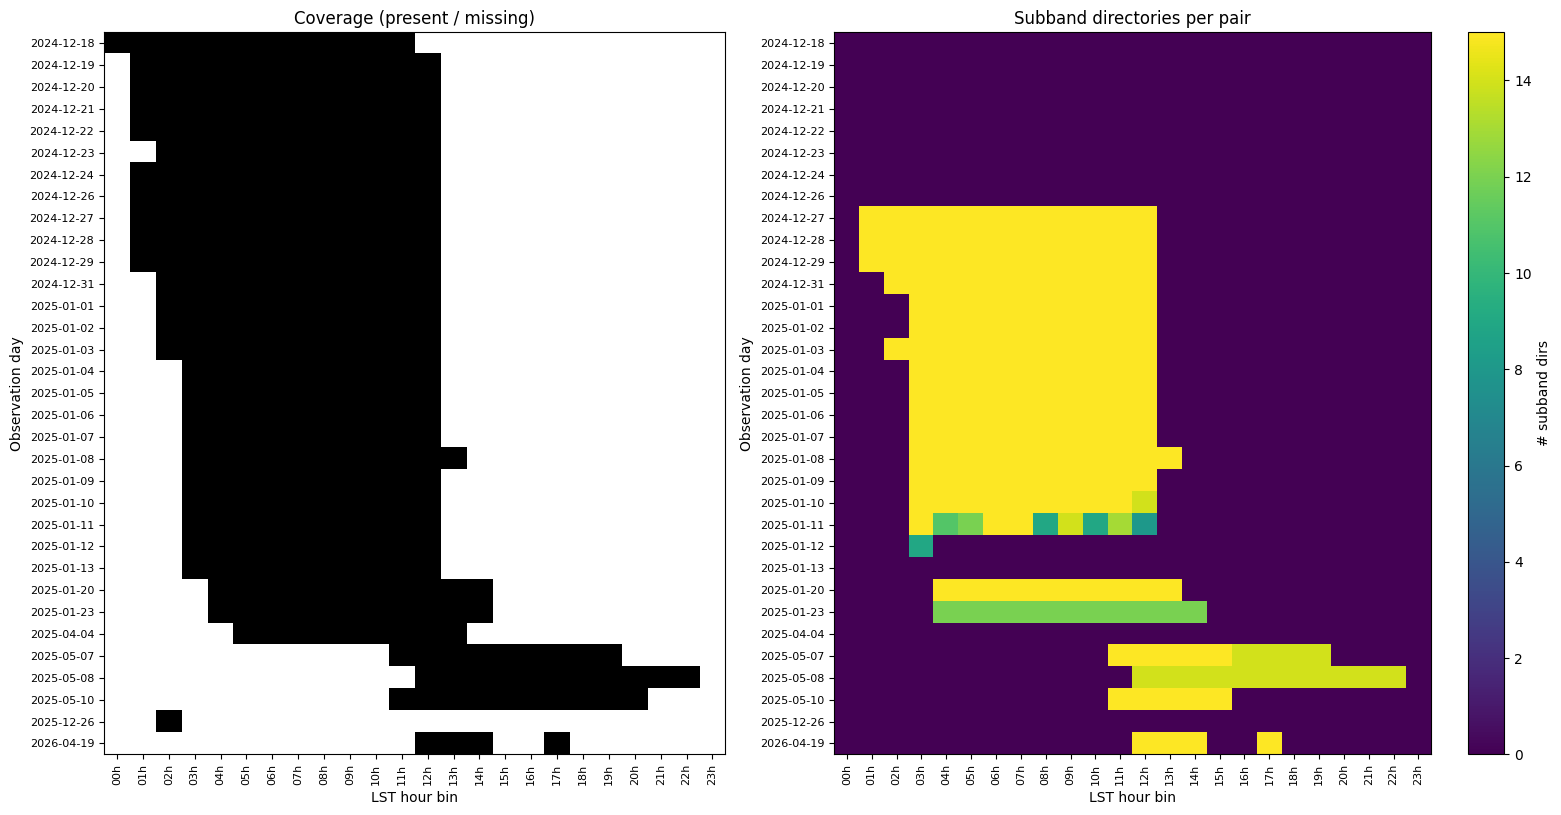

In [6]:
matrix = coverage.pivot_table(
    index="obs_date",
    columns="lst_hour_num",
    values="n_subbands",
    aggfunc="max",
)

all_hours = list(range(24))
matrix = matrix.reindex(columns=all_hours)

hour_labels = [f"{h:02d}h" for h in all_hours]
date_labels = [d.strftime("%Y-%m-%d") for d in matrix.index]

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, 0.25 * len(matrix))), gridspec_kw={"width_ratios": [1, 1.2]})

# Presence mask
presence = matrix.notna().astype(float)
im0 = axes[0].imshow(presence.values, aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("Coverage (present / missing)")
axes[0].set_xticks(range(len(all_hours)))
axes[0].set_xticklabels(hour_labels, rotation=90, fontsize=8)
axes[0].set_yticks(range(len(date_labels)))
axes[0].set_yticklabels(date_labels, fontsize=8)
axes[0].set_xlabel("LST hour bin")
axes[0].set_ylabel("Observation day")

# Subband count where present
subband_vals = matrix.fillna(0).values
im1 = axes[1].imshow(subband_vals, aspect="auto", interpolation="nearest", cmap="viridis")
axes[1].set_title("Subband directories per pair")
axes[1].set_xticks(range(len(all_hours)))
axes[1].set_xticklabels(hour_labels, rotation=90, fontsize=8)
axes[1].set_yticks(range(len(date_labels)))
axes[1].set_yticklabels(date_labels, fontsize=8)
axes[1].set_xlabel("LST hour bin")
axes[1].set_ylabel("Observation day")
fig.colorbar(im1, ax=axes[1], label="# subband dirs")

plt.tight_layout()
plt.show()

## Coverage gaps

Days with fewer than 24 LST hour bins, and hour bins with the fewest days.

In [7]:
max_hours = coverage.groupby("obs_date")["lst_hour"].nunique().max()
incomplete_days = day_summary[day_summary["n_lst_hours"] < max_hours].copy()

print(f"Maximum LST hours covered by any single day: {max_hours}")
print(f"Days with incomplete hour coverage: {len(incomplete_days)}")
display(incomplete_days)

sparse_hours = hour_summary.nsmallest(5, "n_days")
print("\nHour bins with the fewest observation days:")
display(sparse_hours)

Maximum LST hours covered by any single day: 12
Days with incomplete hour coverage: 23


,obs_date,n_lst_hours,lst_hours,n_subbands_min,n_subbands_max,n_subbands_median,n_multi_run_pairs
5,2024-12-23,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",0,0,0.0,1
11,2024-12-31,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",15,15,15.0,0
12,2025-01-01,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",0,15,15.0,1
13,2025-01-02,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",0,15,15.0,0
14,2025-01-03,11,"02h, 03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 1...",15,15,15.0,0
15,2025-01-04,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
16,2025-01-05,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
17,2025-01-06,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
18,2025-01-07,10,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 12h",15,15,15.0,0
19,2025-01-08,11,"03h, 04h, 05h, 06h, 07h, 08h, 09h, 10h, 11h, 1...",15,15,15.0,0



Hour bins with the fewest observation days:


,lst_hour,n_days,first_day,last_day,n_subbands_median
0,00h,1,2024-12-18,2024-12-18,0.0
21,21h,1,2025-05-08,2025-05-08,14.0
22,22h,1,2025-05-08,2025-05-08,14.0
20,20h,2,2025-05-08,2025-05-10,7.0
15,15h,3,2025-05-07,2025-05-10,15.0


## Drill-down: one observation day

Inspect Wideband-qualified `Run_*` directories and subbands for every LST hour
on a chosen day. Defaults to the **earliest** day in the coverage table; change
`SELECT_DAY` if you need a day with Wideband QA (earliest with QA is typically
`2024-12-27`).

In [8]:
SELECT_DAY = "2024-12-27"  # day_summary["obs_date"].iloc[0]  # earliest day by default

day_detail = day_rows(SELECT_DAY)[
    ["lst_hour", "n_runs", "n_wideband_runs", "latest_run", "n_subbands", "subbands", "run_path"]
]

print(f"Detail for {SELECT_DAY} ({len(day_detail)} LST hours with Wideband QA)")
day_detail

Detail for 2024-12-27 (12 LST hours with Wideband QA)


,lst_hour,n_runs,n_wideband_runs,latest_run,n_subbands,subbands,run_path
0,01h,1,1,Run_20260318_172551,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/01h/2024-12-27/Run_202...
1,02h,1,1,Run_20260318_172616,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/02h/2024-12-27/Run_202...
2,03h,1,1,Run_20260318_230759,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/03h/2024-12-27/Run_202...
3,04h,1,1,Run_20260318_230808,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/04h/2024-12-27/Run_202...
4,05h,1,1,Run_20260318_230817,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/05h/2024-12-27/Run_202...
5,06h,1,1,Run_20260318_230829,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/06h/2024-12-27/Run_202...
6,07h,1,1,Run_20260318_230839,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/07h/2024-12-27/Run_202...
7,08h,1,1,Run_20260318_230847,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/08h/2024-12-27/Run_202...
8,09h,1,1,Run_20260318_230855,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/09h/2024-12-27/Run_202...
9,10h,1,1,Run_20260318_230902,15,"18MHz, 23MHz, 27MHz, 32MHz, 36MHz, 41MHz, 46MH...",/lustre/pipeline/images/10h/2024-12-27/Run_202...


## Wideband thermal-noise QA

Display `Wideband/thermal_noise_vs_subband.png` for every LST hour on
`SELECT_DAY` that has a Wideband-qualified run.

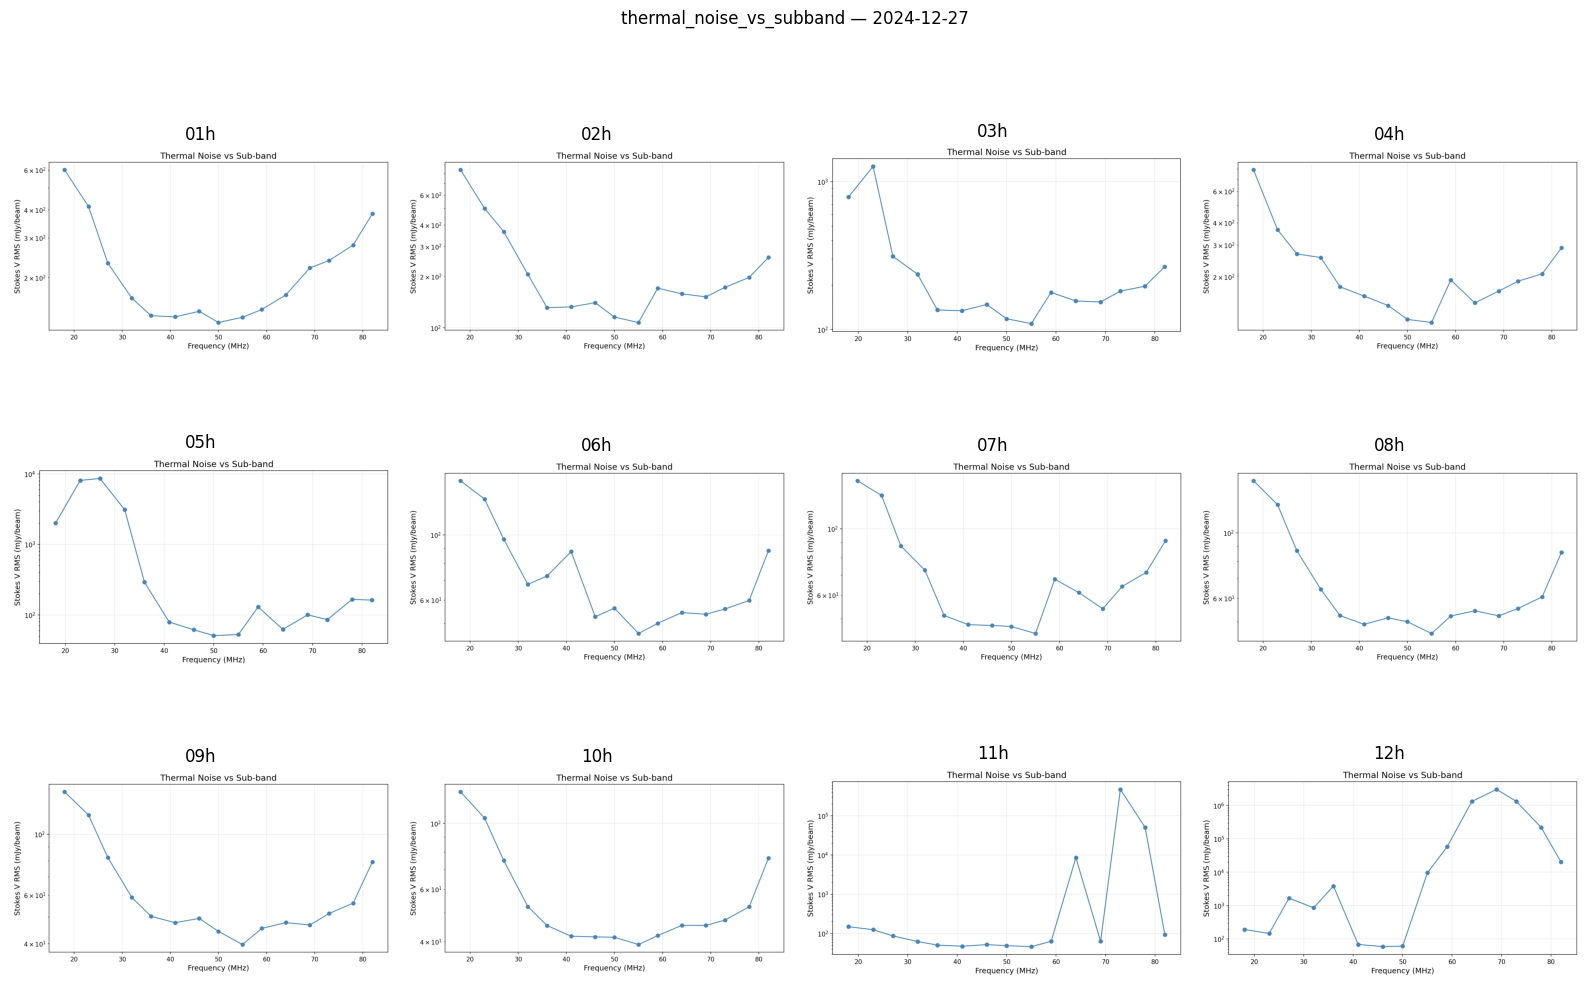

In [9]:
qa_rows = day_rows(SELECT_DAY)

if qa_rows.empty:
    print(f"No Wideband QA runs found for {SELECT_DAY}. Choose a later day or check the tree.")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(qa_rows) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), squeeze=False)

    for ax, (_, row) in zip(axes.ravel(), qa_rows.iterrows()):
        img = mpimg.imread(row["thermal_noise_png"])
        ax.imshow(img)
        ax.set_title(row["lst_hour"])
        ax.axis("off")

    for ax in axes.ravel()[len(qa_rows) :]:
        ax.axis("off")

    fig.suptitle(f"thermal_noise_vs_subband — {SELECT_DAY}", y=1.01)
    plt.tight_layout()
    plt.show()

## FITS → Zarr conversion (Stokes I and V)

Collect deep pbcorr images across all Wideband-qualified hours for the selected
day, symlink them under `/lustre/claw/`, and convert to Zarr stores in
`/fast/claw/`.

| Stokes | FITS pattern |
|--------|--------------|
| I | `{NN}MHz-I-Deep-Taper-Robust-0.75-image-{stamp}.pbcorr.fits` |
| V | `{NN}MHz-V-Taper-Deep-image-{stamp}.pbcorr.fits` |

The LM reference grid is resampled to the **82 MHz** image pixel size.

Stokes **I** is converted first (symlinked from `/lustre/pipeline/images`). Stokes **V**
is staged with beam headers copied from the matching I files, then converted using
the **same LM reference grid** extracted from the I Zarr (avoids rebuilding/resampling
the reference).

In [10]:
qa_rows = day_rows(SELECT_DAY)

if qa_rows.empty:
    raise RuntimeError(
        f"No Wideband-qualified runs for {SELECT_DAY}; cannot collect FITS for conversion."
    )

zarr_paths: dict[str, Path] = {
    "I": qa_zarr_path("I", SELECT_DAY),
    "V": qa_zarr_path("V", SELECT_DAY),
}

if zarr_paths["I"].exists() and zarr_paths["V"].exists():
    print(f"Using existing Zarr stores for {SELECT_DAY}:")
    for pol, path in zarr_paths.items():
        print(f"  Stokes {pol}: {path}")
else:
    TARGET_SIZE = infer_target_size_from_82mhz(SELECT_DAY)
    print(f"LM reference target size from {REF_SUBBAND}: {TARGET_SIZE} px")

    fits_by_pol = {
        "I": collect_pol_fits(SELECT_DAY, "I"),
        "V": collect_pol_fits(SELECT_DAY, "V"),
    }
    for pol, paths in fits_by_pol.items():
        print(f"Stokes {pol}: {len(paths)} FITS files")

    day_tag = SELECT_DAY.replace("-", "")

    if not zarr_paths["I"].exists():
        i_paths = fits_by_pol["I"]
        if not i_paths:
            raise FileNotFoundError(f"No Stokes I FITS found for {SELECT_DAY}")

        staging_i = SYMLINK_ROOT / f"{I_QA_ZARR_STEM}-{day_tag}-fits"
        stage_symlinks(i_paths, staging_i)
        print(f"Staged {len(i_paths)} Stokes I files -> {staging_i}")

        zarr_paths["I"] = convert_fits_dir_to_zarr(
            input_dir=staging_i,
            out_dir=ZARR_ROOT,
            zarr_name=zarr_paths["I"].name,
            fixed_dir=SYMLINK_ROOT / f"{I_QA_ZARR_STEM}-{day_tag}-fixed",
            chunk_lm=1024,
            rebuild=True,
            lm_reference_target_size=TARGET_SIZE,
        )
        print(f"Wrote {zarr_paths['I']}")
    else:
        print(f"Using existing Stokes I Zarr: {zarr_paths['I']}")

    lm_ref_ds = _lm_reference_from_existing_zarr(zarr_paths["I"])

    if not zarr_paths["V"].exists():
        v_paths = fits_by_pol["V"]
        if not v_paths:
            raise FileNotFoundError(f"No Stokes V FITS found for {SELECT_DAY}")

        staging_v = SYMLINK_ROOT / f"{V_QA_ZARR_STEM}-{day_tag}-fits"
        stage_v_fits_with_beam_from_i(v_paths, fits_by_pol["I"], staging_v)
        print(f"Staged {len(v_paths)} Stokes V files -> {staging_v}")

        zarr_paths["V"] = convert_fits_dir_to_zarr(
            input_dir=staging_v,
            out_dir=ZARR_ROOT,
            zarr_name=zarr_paths["V"].name,
            fixed_dir=SYMLINK_ROOT / f"{V_QA_ZARR_STEM}-{day_tag}-fixed",
            chunk_lm=1024,
            rebuild=True,
            lm_reference_ds=lm_ref_ds,
        )
        print(f"Wrote {zarr_paths['V']}")
    else:
        print(f"Using existing Stokes V Zarr: {zarr_paths['V']}")


Using existing Zarr stores for 2024-12-27:
  Stokes I: /fast/claw/pipelineQA-I-Deep-Taper-Robust-0.75-20241227.zarr
  Stokes V: /fast/claw/pipelineQA-V-Taper-Deep-20241227.zarr


## Load converted Zarr stores

In [11]:
if "zarr_paths" not in globals():
    zarr_paths = {
        "I": qa_zarr_path("I", SELECT_DAY),
        "V": qa_zarr_path("V", SELECT_DAY),
    }

datasets: dict[str, xr.Dataset] = {}

for pol, zarr_path in zarr_paths.items():
    if not zarr_path.exists():
        raise FileNotFoundError(
            f"Missing Stokes {pol} Zarr for {SELECT_DAY}: {zarr_path}. "
            "Run the conversion cell above first."
        )
    ds = ovro_lwa_portal.open_dataset(zarr_path, chunks={"l": 512, "m": 512})
    datasets[pol] = ds
    print(f"Stokes {pol}: {zarr_path}")
    print(f"  sizes={dict(ds.sizes)} vars={list(ds.data_vars)}")

datasets["I"], datasets["V"]


Stokes I: /fast/claw/pipelineQA-I-Deep-Taper-Robust-0.75-20241227.zarr
  sizes={'time': 12, 'frequency': 15, 'polarization': 1, 'beam_param': 3, 'l': 3122, 'm': 3122} vars=['BEAM', 'SKY', 'wcs_header_str']
Stokes V: /fast/claw/pipelineQA-V-Taper-Deep-20241227.zarr
  sizes={'time': 12, 'frequency': 15, 'polarization': 1, 'beam_param': 3, 'l': 3122, 'm': 3122} vars=['BEAM', 'SKY', 'wcs_header_str']


/home/claw/code/ovro-lwa-portal/src/ovro_lwa_portal/io.py:687: UserWarning: The specified chunks separate the stored chunks along dimension "l" starting at index 512. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(store, chunks=chunks, **kwargs)
/home/claw/code/ovro-lwa-portal/src/ovro_lwa_portal/io.py:687: UserWarning: The specified chunks separate the stored chunks along dimension "m" starting at index 512. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(store, chunks=chunks, **kwargs)
/home/claw/code/ovro-lwa-portal/src/ovro_lwa_portal/io.py:687: UserWarning: The specified chunks separate the stored chunks along dimension "l" starting at index 512. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(store, chunks=chunks, **kwargs)
/home/claw/code/ovro-lwa-portal/src/ovro_lwa_portal/io.py:687: UserWarning: The specified chunks separate the store

(<xarray.Dataset> Size: 14GB
 Dimensions:          (time: 12, frequency: 15, polarization: 1, beam_param: 3,
                       l: 3122, m: 3122)
 Coordinates:
   * time             (time) float64 96B 6.067e+04 6.067e+04 ... 6.067e+04
   * frequency        (frequency) float64 120B 2.028e+07 2.487e+07 ... 8.459e+07
   * polarization     (polarization) <U1 4B 'I'
   * beam_param       (beam_param) <U5 60B 'major' 'minor' 'pa'
   * l                (l) float64 25kB 1.008 1.007 1.007 ... -1.006 -1.007 -1.007
   * m                (m) float64 25kB -1.008 -1.007 -1.007 ... 1.006 1.007 1.007
     declination      (l, m) float64 78MB dask.array<chunksize=(512, 512), meta=np.ndarray>
     right_ascension  (l, m) float64 78MB dask.array<chunksize=(512, 512), meta=np.ndarray>
     velocity         (time, frequency) float64 1kB dask.array<chunksize=(1, 1), meta=np.ndarray>
 Data variables:
     BEAM             (time, frequency, polarization, beam_param) float64 4kB dask.array<chunksize=(1, 1,

## 5. Interactive review: zenith patch STD + SkyWidget (Stokes I)

Spatial **standard deviation** in a ~20-pixel patch at fixed `(l=0`, `m=0)`
for each `(time, frequency)` cell of the Stokes **I** Zarr. Click the
heatmap to move the crosshair; the linked SkyWidget loads that slice and
centers on the `(l=0, m=0)` sky position for the selected time.

Shared helpers live in the next cell; section 6 repeats the workflow for
Stokes **V** using patch **RMS**.


In [ ]:
import holoviews as hv
import ipywidgets as widgets
import panel as pn
from astropy.coordinates import SkyCoord
import astropy.units as u
from astrowidget import SkyWidget
from holoviews import streams

ZENITH_L = 0.0
ZENITH_M = 0.0
ZENITH_PATCH_RADIUS = 10  # patch spans [center±radius] → 21 pixels (~20 px)
DEFAULT_FREQ_IDX = 8
DEFAULT_FOV_DEG = 25.0


def first_valid_time_idx(dataset: xr.Dataset, freq_idx: int) -> int:
    """First time index where SKY has finite data at the given frequency."""
    sky = dataset.SKY.isel(frequency=freq_idx)
    for t in range(sky.sizes["time"]):
        if np.isfinite(sky.isel(time=t).values).any():
            return t
    return 0


def zenith_lm_coord(dataset: xr.Dataset, time_idx: int) -> SkyCoord:
    """RA/Dec of the fixed (l=0, m=0) grid point for one time slice."""
    wcs = dataset.radport._get_wcs(time_idx=time_idx)
    l_idx, m_idx = dataset.radport.nearest_lm_idx(ZENITH_L, ZENITH_M)
    coord = wcs.pixel_to_world(l_idx, m_idx)
    return SkyCoord(ra=coord.ra, dec=coord.dec)


def _reduce_patch_rms(patch: np.ndarray) -> np.ndarray:
    """RMS = sqrt(mean(x^2)) for each frequency plane (Stokes V about zero)."""
    patch_arr = np.asarray(patch)
    values = np.full(patch_arr.shape[0], np.nan, dtype=np.float64)
    for fi in range(patch_arr.shape[0]):
        finite = patch_arr[fi][np.isfinite(patch_arr[fi])]
        if finite.size:
            values[fi] = np.sqrt(np.mean(finite**2))
    return values


def compute_zenith_std_map(dataset: xr.Dataset, radius: int = ZENITH_PATCH_RADIUS) -> np.ndarray:
    """Spatial STD in a fixed (l=0, m=0) patch for each (time, frequency) cell."""
    result = dataset.radport.patch_statistic(
        l=ZENITH_L,
        m=ZENITH_M,
        statistic="std",
        radius=radius,
    )
    return np.asarray(result.stat_map.values, dtype=np.float64)


def compute_zenith_rms_map(dataset: xr.Dataset, radius: int = ZENITH_PATCH_RADIUS) -> np.ndarray:
    """Spatial RMS in a fixed (l=0, m=0) patch for each (time, frequency) cell."""
    l_idx, m_idx = dataset.radport.nearest_lm_idx(ZENITH_L, ZENITH_M)
    n_times = int(dataset.sizes["time"])
    n_freqs = int(dataset.sizes["frequency"])
    stat_map = np.full((n_times, n_freqs), np.nan, dtype=np.float64)
    vis_times, patches = dataset.radport._extract_tracked_patch_cubes(
        l_indices=np.full(n_times, l_idx, dtype=int),
        m_indices=np.full(n_times, m_idx, dtype=int),
        visible=np.ones(n_times, dtype=bool),
        var="SKY",
        pol=0,
        radius=radius,
    )
    for ti, patch in zip(vis_times, patches, strict=True):
        stat_map[int(ti)] = _reduce_patch_rms(np.asarray(patch))
    return stat_map


def build_zenith_review_panel(
    dataset: xr.Dataset,
    stat_map: np.ndarray,
    *,
    stokes_label: str,
    metric_label: str,
):
    """Interactive heatmap + SkyWidget centered on (l=0, m=0) for each time slice."""
    n_times = int(dataset.sizes["time"])
    n_freqs = int(dataset.sizes["frequency"])
    default_time_idx = first_valid_time_idx(dataset, DEFAULT_FREQ_IDX)

    sky_widget = SkyWidget()
    sky_widget.set_dataset(dataset, max_size=dataset.sizes["l"] // 2)
    sky_widget.background_survey = "DSS"
    sky_widget.colormap = "inferno"
    sky_widget.stretch = "sqrt"
    sky_widget.invert_horizontal_pan = True
    sky_widget.layout = widgets.Layout(
        min_width="520px",
        min_height="620px",
        width="100%",
        height="620px",
    )

    time_slider = pn.widgets.IntSlider(
        name="Time idx",
        start=0,
        end=n_times - 1,
        value=default_time_idx,
    )
    freq_slider = pn.widgets.IntSlider(
        name="Freq idx",
        start=0,
        end=n_freqs - 1,
        value=DEFAULT_FREQ_IDX,
    )
    fov_slider = pn.widgets.FloatSlider(
        name="FOV (deg)",
        start=1.0,
        end=45.0,
        step=0.5,
        value=DEFAULT_FOV_DEG,
    )
    status_pane = pn.pane.Markdown("")

    slice_tap = streams.Tap(transient=True)

    def _sync_sky(time_idx: int, freq_idx: int, fov_deg: float) -> None:
        coord = zenith_lm_coord(dataset, time_idx)
        sky_widget.update_slice(
            time_idx,
            freq_idx,
            center=coord,
            fov=fov_deg * u.deg,
            percentile_low=2,
            percentile_high=98,
        )
        metric_val = float(stat_map[time_idx, freq_idx])
        freq_mhz = float(dataset.frequency.values[freq_idx]) / 1e6
        status_pane.object = (
            f"**Stokes {stokes_label} zenith (l=0, m=0)** | time={time_idx}, "
            f"freq={freq_idx} ({freq_mhz:.1f} MHz)"
            f" | center RA={coord.ra.to_string(unit=u.hour, precision=1)}, "
            f"Dec={coord.dec.to_string(unit=u.deg, precision=1)}"
            f" | patch {metric_label}={metric_val:.3g}"
        )

    def _on_slice_tap(x, y):
        if x is None or y is None:
            return
        new_time = int(np.clip(round(x), 0, n_times - 1))
        new_freq = int(np.clip(round(y), 0, n_freqs - 1))
        time_slider.value = new_time
        freq_slider.value = new_freq
        _sync_sky(new_time, new_freq, fov_slider.value)

    slice_tap.add_subscriber(_on_slice_tap)

    def _on_control_change(event=None):
        _sync_sky(time_slider.value, freq_slider.value, fov_slider.value)

    for _widget in (time_slider, freq_slider, fov_slider):
        _widget.param.watch(_on_control_change, "value")

    @pn.depends(time_idx=time_slider, freq_idx=freq_slider)
    def zenith_metric_heatmap(time_idx, freq_idx):
        times = np.arange(stat_map.shape[0])
        freqs = np.arange(stat_map.shape[1])

        finite = stat_map[np.isfinite(stat_map)]
        clim = tuple(np.percentile(finite, [2, 98]).astype(float)) if finite.size else (None, None)

        img = hv.Image(
            (times, freqs, stat_map.T),
            kdims=["time_idx", "freq_idx"],
            label=f"Zenith patch {metric_label} (click to set slice)",
        ).opts(cmap="viridis", colorbar=True, clim=clim, tools=["hover", "tap"])
        crosshair = (
            hv.VLine(time_idx).opts(color="cyan", line_width=2)
            * hv.HLine(freq_idx).opts(color="cyan", line_width=2)
        )
        plot = img * crosshair
        slice_tap.source = plot
        return plot.opts(
            width=520,
            height=380,
            xlabel="Time index",
            ylabel="Frequency index",
        )

    controls = pn.Row(time_slider, freq_slider, fov_slider)
    heatmap_pane = pn.panel(zenith_metric_heatmap, sizing_mode="stretch_width")
    sky_pane = pn.pane.IPyWidget(sky_widget, sizing_mode="stretch_both", min_height=620)

    panel = pn.Column(
        controls,
        status_pane,
        pn.Row(heatmap_pane, sky_pane, sizing_mode="stretch_width"),
        sizing_mode="stretch_width",
    )
    _sync_sky(default_time_idx, DEFAULT_FREQ_IDX, DEFAULT_FOV_DEG)
    return panel


In [ ]:
ds_i = datasets["I"]
print(
    f"Computing Stokes I zenith patch STD (l={ZENITH_L}, m={ZENITH_M}, "
    f"radius={ZENITH_PATCH_RADIUS}, ~{2 * ZENITH_PATCH_RADIUS + 1} px)…"
)
std_map_i = compute_zenith_std_map(ds_i)
l_zen_idx, m_zen_idx = ds_i.radport.nearest_lm_idx(ZENITH_L, ZENITH_M)
finite_std = std_map_i[np.isfinite(std_map_i)]
if finite_std.size:
    print(
        f"  zenith pixel=({l_zen_idx}, {m_zen_idx})  "
        f"STD [{finite_std.min():.3g}, {finite_std.max():.3g}] "
        f"(p95={np.percentile(finite_std, 95):.3g})"
    )
else:
    print("  [no finite STD values]")

pn.extension()
hv.extension("bokeh")

review_panel_i = build_zenith_review_panel(
    ds_i,
    std_map_i,
    stokes_label="I",
    metric_label="STD",
)
review_panel_i


## 6. Interactive review: zenith patch RMS + SkyWidget (Stokes V)

Same layout as section 5, but for the Stokes **V** Zarr. Spatial **RMS**
(`sqrt(mean(x²))`) in the ~20-pixel patch at fixed `(l=0, m=0)`; the
SkyWidget recenters on that grid point for each selected time slice.


In [ ]:
if "V" not in datasets:
    raise RuntimeError("Stokes V Zarr was not loaded — run the conversion cell first.")

ds_v = datasets["V"]
print(
    f"Computing Stokes V zenith patch RMS (l={ZENITH_L}, m={ZENITH_M}, "
    f"radius={ZENITH_PATCH_RADIUS}, ~{2 * ZENITH_PATCH_RADIUS + 1} px)…"
)
rms_map_v = compute_zenith_rms_map(ds_v)
l_zen_idx, m_zen_idx = ds_v.radport.nearest_lm_idx(ZENITH_L, ZENITH_M)
finite_rms = rms_map_v[np.isfinite(rms_map_v)]
if finite_rms.size:
    print(
        f"  zenith pixel=({l_zen_idx}, {m_zen_idx})  "
        f"RMS [{finite_rms.min():.3g}, {finite_rms.max():.3g}] "
        f"(p95={np.percentile(finite_rms, 95):.3g})"
    )
else:
    print("  [no finite RMS values]")

review_panel_v = build_zenith_review_panel(
    ds_v,
    rms_map_v,
    stokes_label="V",
    metric_label="RMS",
)
review_panel_v
